In [178]:
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

In [179]:
df = pd.read_csv("data/kickstarter_projects.csv")

In [180]:
df.head()

,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374853 entries, 0 to 374852
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   ID           374853 non-null  int64 
 1   Name         374853 non-null  object
 2   Category     374853 non-null  object
 3   Subcategory  374853 non-null  object
 4   Country      374853 non-null  object
 5   Launched     374853 non-null  object
 6   Deadline     374853 non-null  object
 7   Goal         374853 non-null  int64 
 8   Pledged      374853 non-null  int64 
 9   Backers      374853 non-null  int64 
 10  State        374853 non-null  object
dtypes: int64(4), object(7)
memory usage: 31.5+ MB


ID - Project ID.  
Name - Project Name.  
Category - 15 different categories.   
Subcategory - 159 different subcategories.  
Country - 22 different countries.   
Launched - In object form.  
Deadline - In object form.  
Goal - Set dollar amount.  
Pledged - Achieved dollar amount.  
Backers - Amount of people backing the project.  
State - Target feature - 5 different outcomes.


In [182]:
df.describe()

,ID,Goal,Pledged,Backers
count,3.748530e+05,3.748530e+05,3.748530e+05,374853.000000
mean,1.074656e+09,4.586378e+04,9.121073e+03,106.690359
std,6.191377e+08,1.158778e+06,9.132054e+04,911.718520
min,5.971000e+03,0.000000e+00,0.000000e+00,0.000000
25%,5.380728e+08,2.000000e+03,3.100000e+01,2.000000
50%,1.075300e+09,5.500000e+03,6.250000e+02,12.000000
75%,1.610149e+09,1.600000e+04,4.051000e+03,57.000000
max,2.147476e+09,1.663614e+08,2.033899e+07,219382.000000


In [ ]:
# Convert Datetime columns to correct format:

df['Launched'] = pd.to_datetime(df['Launched'])
df['Deadline'] = pd.to_datetime(df['Deadline'])

In [184]:
df.head()

,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


In [ ]:
# Seperate date and time:

df['Launch_Time'] = (df['Launched']).dt.time
df['Launched'] = (df['Launched']).dt.date

In [188]:
df.head()

,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State,Launch_Time
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21,2009-05-31,1000,625,30,Failed,21:02:48
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23,2009-07-20,80000,22,3,Failed,00:07:53
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24,2009-05-03,20,35,3,Successful,21:52:03
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25,2009-07-14,99,145,25,Successful,17:36:21
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27,2009-05-26,1900,387,10,Failed,14:10:39


In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374853 entries, 0 to 374852
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   ID           374853 non-null  int64         
 1   Name         374853 non-null  object        
 2   Category     374853 non-null  object        
 3   Subcategory  374853 non-null  object        
 4   Country      374853 non-null  object        
 5   Launched     374853 non-null  object        
 6   Deadline     374853 non-null  datetime64[ns]
 7   Goal         374853 non-null  int64         
 8   Pledged      374853 non-null  int64         
 9   Backers      374853 non-null  int64         
 10  State        374853 non-null  object        
 11  Launch_Time  374853 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(7)
memory usage: 34.3+ MB


In [ ]:
# Convert back to Datetime format:
df['Launched'] = pd.to_datetime(df['Launched'])
df['Launch_Time'] = pd.to_datetime(df['Launch_Time'].astype(str))

In [ ]:
# Calculate days to deadline:
df['Days_to_Deadline'] = (df['Deadline'] - df['Launched']).dt.days

In [ ]:
# Create backup before feature tuning:
inital_backup_df = df

In [194]:
inital_backup_df.columns

Index(['ID', 'Name', 'Category', 'Subcategory', 'Country', 'Launched',
       'Deadline', 'Goal', 'Pledged', 'Backers', 'State', 'Launch_Time',
       'Days_to_Deadline'],
      dtype='object')

In [195]:
inital_backup_df.shape

(374853, 13)

In [ ]:
# Define feature groups
df_identifiers = df[['ID', 'Name']]
df_categorical = df[['Category', 'Subcategory', 'Country']]
df_numerical = df[['Goal', 'Pledged', 'Backers', 'Days_to_Deadline']]
target = df[['State']]

In [ ]:
# Create new df with dummies - used as backup:
complete_df = pd.concat([df, pd.get_dummies(df_categorical)], axis=1)

In [ ]:
# Create df to work with:
work_df = complete_df
work_df.columns

Index(['ID', 'Name', 'Category', 'Subcategory', 'Country', 'Launched',
       'Deadline', 'Goal', 'Pledged', 'Backers',
       ...
       'Country_Mexico', 'Country_Netherlands ', 'Country_New Zealand',
       'Country_Norway', 'Country_Singapore', 'Country_Spain',
       'Country_Sweden', 'Country_Switzerland', 'Country_United Kingdom',
       'Country_United States'],
      dtype='object', length=209)

In [ ]:
# Drop identifying columns:
work_df = complete_df.drop(columns=df_identifiers.columns)
work_df.columns

Index(['Category', 'Subcategory', 'Country', 'Launched', 'Deadline', 'Goal',
       'Pledged', 'Backers', 'State', 'Launch_Time',
       ...
       'Country_Mexico', 'Country_Netherlands ', 'Country_New Zealand',
       'Country_Norway', 'Country_Singapore', 'Country_Spain',
       'Country_Sweden', 'Country_Switzerland', 'Country_United Kingdom',
       'Country_United States'],
      dtype='object', length=207)

In [ ]:
# Normalize numerical columns:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
work_df[df_numerical.columns] = scaler.fit_transform(work_df[df_numerical.columns])

In [ ]:
# Drop categorical columns - they have dummies now:
work_df = work_df.drop(columns=df_categorical.columns)

In [213]:
list(work_df.columns)

['Launched',
 'Deadline',
 'Goal',
 'Pledged',
 'Backers',
 'State',
 'Launch_Time',
 'Days_to_Deadline',
 'Category_Art',
 'Category_Comics',
 'Category_Crafts',
 'Category_Dance',
 'Category_Design',
 'Category_Fashion',
 'Category_Film & Video',
 'Category_Food',
 'Category_Games',
 'Category_Journalism',
 'Category_Music',
 'Category_Photography',
 'Category_Publishing',
 'Category_Technology',
 'Category_Theater',
 'Subcategory_3D Printing',
 'Subcategory_Academic',
 'Subcategory_Accessories',
 'Subcategory_Action',
 'Subcategory_Animals',
 'Subcategory_Animation',
 'Subcategory_Anthologies',
 'Subcategory_Apparel',
 'Subcategory_Apps',
 'Subcategory_Architecture',
 'Subcategory_Art',
 'Subcategory_Art Books',
 'Subcategory_Audio',
 'Subcategory_Bacon',
 'Subcategory_Blues',
 'Subcategory_Calendars',
 'Subcategory_Camera Equipment',
 'Subcategory_Candles',
 'Subcategory_Ceramics',
 "Subcategory_Children's Books",
 'Subcategory_Childrenswear',
 'Subcategory_Chiptune',
 'Subcategory

In [ ]:
# Create df for only numerical values:
numerical_corr = inital_backup_df.drop(columns=['ID', 'Name', 'Subcategory', 'Launch_Time'])
numerical_corr = numerical_corr.drop(columns=['Country'])

In [216]:
numerical_corr.Category.unique()

array(['Fashion', 'Film & Video', 'Art', 'Technology', 'Journalism',
       'Publishing', 'Theater', 'Music', 'Photography', 'Games', 'Design',
       'Food', 'Crafts', 'Comics', 'Dance'], dtype=object)

In [ ]:
# Create mapping for categories:
category_map = {c:i for i,c in enumerate(numerical_corr['Category'].unique())}

In [ ]:
# Map numerical categories according to mapping:
numerical_corr['Category_num'] = numerical_corr['Category'].map(category_map)

In [219]:
numerical_corr.columns

Index(['Category', 'Launched', 'Deadline', 'Goal', 'Pledged', 'Backers',
       'State', 'Days_to_Deadline', 'Category_num'],
      dtype='object')

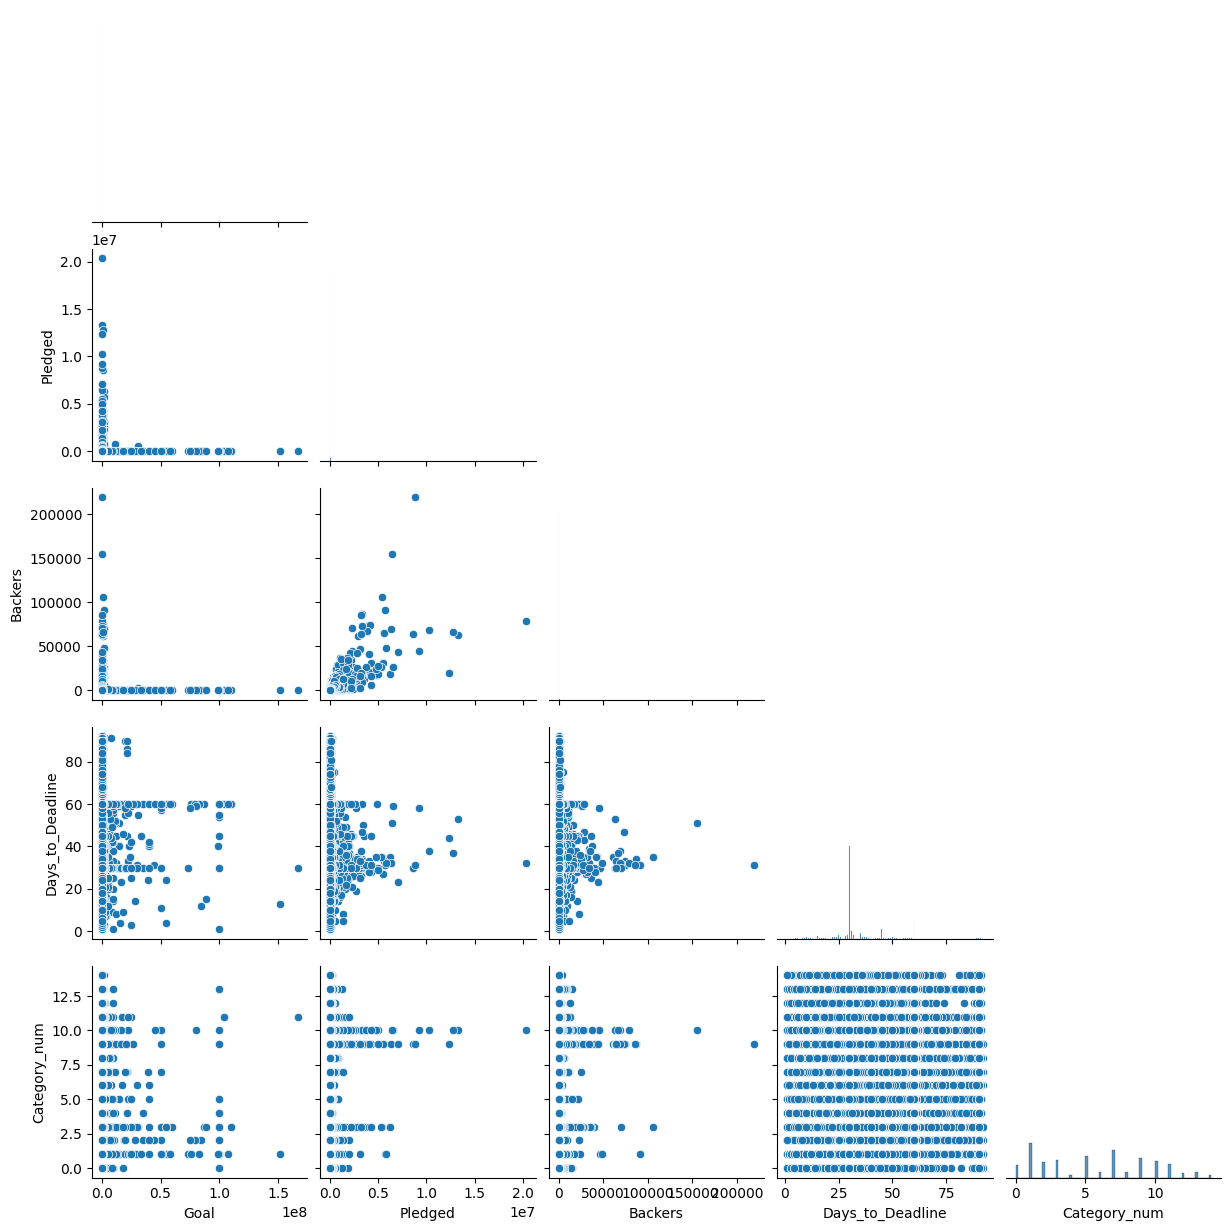

In [ ]:
# Plot numerical correlations:
sns.pairplot(numerical_corr, corner=True)

<Axes: xlabel='Backers', ylabel='Pledged'>

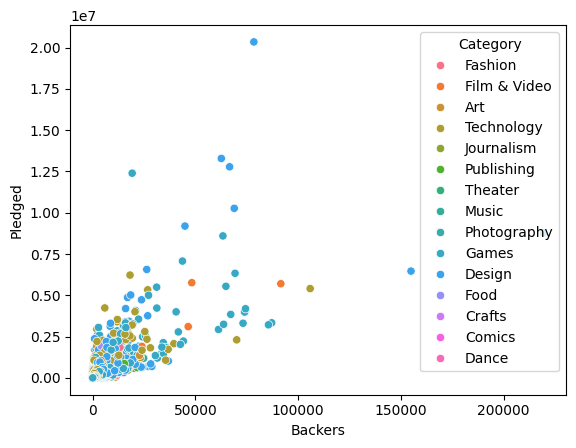

In [221]:
sns.scatterplot(inital_backup_df, x='Backers', y='Pledged', hue='Category')

In [229]:
work_df['State'].value_counts()

State
Failed        238204
Successful    133851
Name: count, dtype: int64

In [ ]:
# Define canceled and suspended projects as failed:
work_df.loc[work_df['State'].str.contains('Canceled'), 'State'] = 'Failed'
work_df.loc[work_df['State'].str.contains('Suspended'), 'State'] = 'Failed'

In [ ]:
# Drop projects that are still live:
work_df = work_df[work_df['State'] != 'Live']

In [ ]:
# Define failed as 0 and successful as 1:
work_df.loc[work_df['State'].str.contains('Failed'), 'State'] = '0'
work_df.loc[work_df['State'].str.contains('Successful'), 'State'] = '1'

In [ ]:
# Convert to integers:
work_df['State'] = work_df['State'].astype(int)

In [233]:
work_df['State'].info()

<class 'pandas.core.series.Series'>
Index: 372055 entries, 0 to 374823
Series name: State
Non-Null Count   Dtype
--------------   -----
372055 non-null  int64
dtypes: int64(1)
memory usage: 5.7 MB


In [234]:
work_df.shape

(372055, 204)

In [69]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.metrics import accuracy_score

In [235]:
work_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 372055 entries, 0 to 374823
Columns: 204 entries, Launched to Country_United States
dtypes: bool(196), datetime64[ns](3), float64(4), int64(1)
memory usage: 95.1 MB


In [ ]:
# Convert datetime columns into seperate columns:
work_df['launch_year'] = work_df['Launched'].dt.year
work_df['launch_month'] = work_df['Launched'].dt.month
work_df['launch_dayofweek'] = work_df['Launched'].dt.dayofweek
work_df['launch_hour'] = work_df['Launch_Time'].dt.hour

In [ ]:
# Drop original datetime columns:
work_df = work_df.drop(columns=['Launched', 'Launch_Time', 'Deadline'])

In [238]:
work_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 372055 entries, 0 to 374823
Columns: 205 entries, Goal to launch_hour
dtypes: bool(196), float64(4), int32(4), int64(1)
memory usage: 92.3 MB


In [ ]:
# Force all columns to be numerical:
work_df = work_df.apply(pd.to_numeric, errors='ignore')

/var/folders/tw/38530zcs4yj299v2r5q1h8vr0000gn/T/ipykernel_75254/1612881832.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  work_df = work_df.apply(pd.to_numeric, errors='ignore')


In [240]:
work_df.shape

(372055, 205)

In [ ]:
# Initial split:
X = work_df.drop(columns='State', axis=1)
y = work_df['State']

In [242]:
X.shape

(372055, 204)

In [243]:
y.shape

(372055,)

In [244]:
RSEED = 42

In [245]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=RSEED)

In [ ]:
# Create a loop that tests models on data:
models = [DecisionTreeClassifier(random_state=RSEED),
          XGBClassifier(random_state=RSEED), 
          AdaBoostClassifier(random_state=RSEED),
          KNeighborsClassifier(),
          RandomForestClassifier(random_state=RSEED)] 



for model in models: 
    model.fit(X_train, y_train) 
    preds = model.predict(X_test) 
    name = type(model).__name__
    print(f'For the {name}\nAccuracy:{round(accuracy_score(y_test, preds),3)}\nRecall:{round(recall_score(y_test, preds),3)}\nPrecision:{round(precision_score(y_test, preds),3)}\nF1:{round(f1_score(y_test, preds),3)}') 

    

For the DecisionTreeClassifier
Accuracy:0.993
Recall:0.99
Precision:0.99
F1:0.99
For the XGBClassifier
Accuracy:0.996
Recall:0.999
Precision:0.989
F1:0.994
For the AdaBoostClassifier
Accuracy:0.958
Recall:0.955
Precision:0.93
F1:0.942
For the KNeighborsClassifier
Accuracy:0.662
Recall:0.419
Precision:0.538
F1:0.471
For the RandomForestClassifier
Accuracy:0.983
Recall:0.987
Precision:0.966
F1:0.976


In [ ]:
# Second split - dropping pledged:
X2 = work_df.drop(columns=['State', 'Pledged'], axis=1)
y2 = work_df['State']

In [268]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, stratify=y, random_state=RSEED)

In [ ]:
# Run model loop for the second split:
models = [DecisionTreeClassifier(random_state=RSEED),
          XGBClassifier(random_state=RSEED), 
          AdaBoostClassifier(random_state=RSEED),
          KNeighborsClassifier(),
          RandomForestClassifier(random_state=RSEED)] 



for model in models: 
    model.fit(X_train2, y_train2) 
    preds = model.predict(X_test2) 
    name = type(model).__name__
    print(f'For the {name}\nAccuracy:{round(accuracy_score(y_test2, preds),3)}\nRecall:{round(recall_score(y_test2, preds),3)}\nPrecision:{round(precision_score(y_test2, preds),3)}\nF1:{round(f1_score(y_test2, preds),3)}') 

    

For the DecisionTreeClassifier
Accuracy:0.902
Recall:0.863
Precision:0.865
F1:0.864
For the XGBClassifier
Accuracy:0.935
Recall:0.919
Precision:0.902
F1:0.911
For the AdaBoostClassifier
Accuracy:0.92
Recall:0.894
Precision:0.883
F1:0.889
For the KNeighborsClassifier
Accuracy:0.662
Recall:0.423
Precision:0.539
F1:0.474
For the RandomForestClassifier
Accuracy:0.93
Recall:0.91
Precision:0.897
F1:0.904


In [ ]:
# Create third split - drop backers as well:
X3 = work_df.drop(columns=['State', 'Pledged', 'Backers'], axis=1)
y3 = work_df['State']

In [290]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, stratify=y, random_state=RSEED)

In [ ]:
# Run loop on third split:
models = [DecisionTreeClassifier(random_state=RSEED),
          XGBClassifier(random_state=RSEED), 
          AdaBoostClassifier(random_state=RSEED),
          DecisionTreeClassifier(),
          RandomForestClassifier(random_state=RSEED)] 



for model in models: 
    model.fit(X_train3, y_train3) 
    preds = model.predict(X_test3) 
    name = type(model).__name__
    print(f'For the {name}\nAccuracy:{round(accuracy_score(y_test3, preds),3)}\nRecall:{round(recall_score(y_test3, preds),3)}\nPrecision:{round(precision_score(y_test3, preds),3)}\nF1:{round(f1_score(y_test3, preds),3)}') 

    

For the DecisionTreeClassifier
Accuracy:0.624
Recall:0.481
Precision:0.478
F1:0.479
For the XGBClassifier
Accuracy:0.71
Recall:0.462
Precision:0.633
F1:0.534
For the AdaBoostClassifier
Accuracy:0.668
Recall:0.324
Precision:0.568
F1:0.413
For the DecisionTreeClassifier
Accuracy:0.624
Recall:0.481
Precision:0.478
F1:0.479
For the RandomForestClassifier
Accuracy:0.696
Recall:0.443
Precision:0.605
F1:0.512


In [277]:
y.shape

(372055,)

In [ ]:
# Create baseline predictions:
y_baseline = np.ones(93014,)

In [304]:
y_baseline.shape

(93014,)

In [305]:
X_test3.shape

(93014, 202)

In [313]:
models = [DecisionTreeClassifier(random_state=RSEED),
          XGBClassifier(random_state=RSEED), 
          AdaBoostClassifier(random_state=RSEED),
          KNeighborsClassifier(),
          RandomForestClassifier(random_state=RSEED)] 



for model in models: 
    model.fit(X_train3, y_train3) 
    preds = model.predict(X_test3) 
    name = type(model).__name__
    print(f'For the {name}\nAccuracy:{round(accuracy_score(y_test3, y_baseline),3)}\nRecall:{round(recall_score(y_test3, y_baseline),3)}\nPrecision:{round(precision_score(y_test3, y_baseline),3)}\nF1:{round(f1_score(y_test3, y_baseline),3)}') 

    

For the DecisionTreeClassifier
Accuracy:0.36
Recall:1.0
Precision:0.36
F1:0.529
For the XGBClassifier
Accuracy:0.36
Recall:1.0
Precision:0.36
F1:0.529
For the AdaBoostClassifier
Accuracy:0.36
Recall:1.0
Precision:0.36
F1:0.529
For the KNeighborsClassifier
Accuracy:0.36
Recall:1.0
Precision:0.36
F1:0.529
For the RandomForestClassifier
Accuracy:0.36
Recall:1.0
Precision:0.36
F1:0.529
